# Assignment II

---

## Overview

This notebook solves the supervised regression problem of predicting **hourly bike rentals** using the UCI Bike Sharing Dataset (hour.csv). The workflow is iterative: EDA informs feature engineering; training exposes bias-variance trade-offs; tuning corrects them. Three models of increasing complexity are compared — Linear Regression (baseline), Random Forest, and Gradient Boosting — and the best is evaluated on a held-out test set.

**Problem statement:** Given hourly weather, temporal, and seasonal features, predict the total count of bike rentals (cnt) per hour.

GITHUB REPO: https://github.com/rmetchkarovaieu2024-bit/ML-fundamentals-2026

In [31]:
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


## Imports and Global Settings

In [32]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from skopt import BayesSearchCV
from skopt.space import Real, Integer

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded. NumPy:', np.__version__, '| pandas:', pd.__version__)


Libraries loaded. NumPy: 2.0.2 | pandas: 2.3.3


---
## Task 1 — Exploratory Data Analysis

EDA serves two purposes: (1) build analytical intuition about what drives rental demand, and (2) surface data quality issues and structural patterns that guide feature engineering. We examine the target variable, temporal features, binary flags, weather variables, and inter-feature correlations.

### Load and Inspect the Dataset

In [33]:
# Fetch the Bike Sharing Dataset from UCI ML Repository (id=275 = hourly data)
bike_sharing = fetch_ucirepo(id=275)

# Print metadata and variable information
print(bike_sharing.metadata)
print(bike_sharing.variables)

# Combine features and target into a single DataFrame (mirrors the original hour.csv structure)
df = pd.concat([bike_sharing.data.features, bike_sharing.data.targets], axis=1)

print(f'\nShape: {df.shape}')
print('\nColumn data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
df.head()


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [34]:
print(df.describe().round(3).to_string())

          season         yr       mnth         hr    holiday    weekday  workingday  weathersit       temp      atemp        hum  windspeed        cnt
count  17379.000  17379.000  17379.000  17379.000  17379.000  17379.000   17379.000   17379.000  17379.000  17379.000  17379.000  17379.000  17379.000
mean       2.502      0.503      6.538     11.547      0.029      3.004       0.683       1.425      0.497      0.476      0.627      0.190    189.463
std        1.107      0.500      3.439      6.914      0.167      2.006       0.465       0.639      0.193      0.172      0.193      0.122    181.388
min        1.000      0.000      1.000      0.000      0.000      0.000       0.000       1.000      0.020      0.000      0.000      0.000      1.000
25%        2.000      0.000      4.000      6.000      0.000      1.000       0.000       1.000      0.340      0.333      0.480      0.104     40.000
50%        3.000      1.000      7.000     12.000      0.000      3.000       1.000       1.00

In [35]:

cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print('Retained features:', df.columns.tolist())

Retained features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


### Target Variable Distribution

Understanding cnt's distribution is critical because regression model assumptions concern the target's marginal distribution and residual distribution. A heavy right skew typical of count data suggests a log-transform may improve model fit.

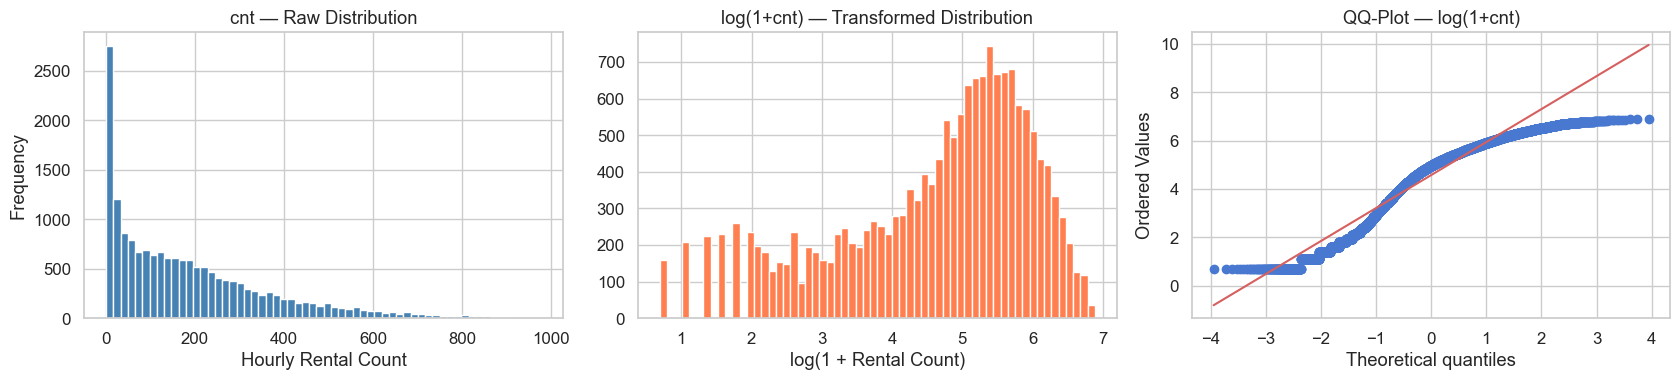

cnt        — skewness: 1.277 | kurtosis: 1.417
log1p(cnt) — skewness: -0.818 | kurtosis: -0.180


In [36]:
log_cnt = np.log1p(df['cnt'])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(df['cnt'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('cnt — Raw Distribution')
axes[0].set_xlabel('Hourly Rental Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(log_cnt, bins=60, color='coral', edgecolor='white')
axes[1].set_title('log(1+cnt) — Transformed Distribution')
axes[1].set_xlabel('log(1 + Rental Count)')

stats.probplot(log_cnt, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot — log(1+cnt)')

plt.tight_layout()
plt.show()

print(f'cnt        — skewness: {df["cnt"].skew():.3f} | kurtosis: {df["cnt"].kurt():.3f}')
print(f'log1p(cnt) — skewness: {log_cnt.skew():.3f} | kurtosis: {log_cnt.kurt():.3f}')

**Analytical finding:** Raw cnt is moderately right-skewed. Applying log(1 + cnt) brings skewness close to zero and the QQ-plot shows a better normal approximation in the bulk. Working in log-space particularly benefits Linear Regression (more sensitive to residual non-normality) and produces a more stable loss surface for ensemble models.

### Temporal Features

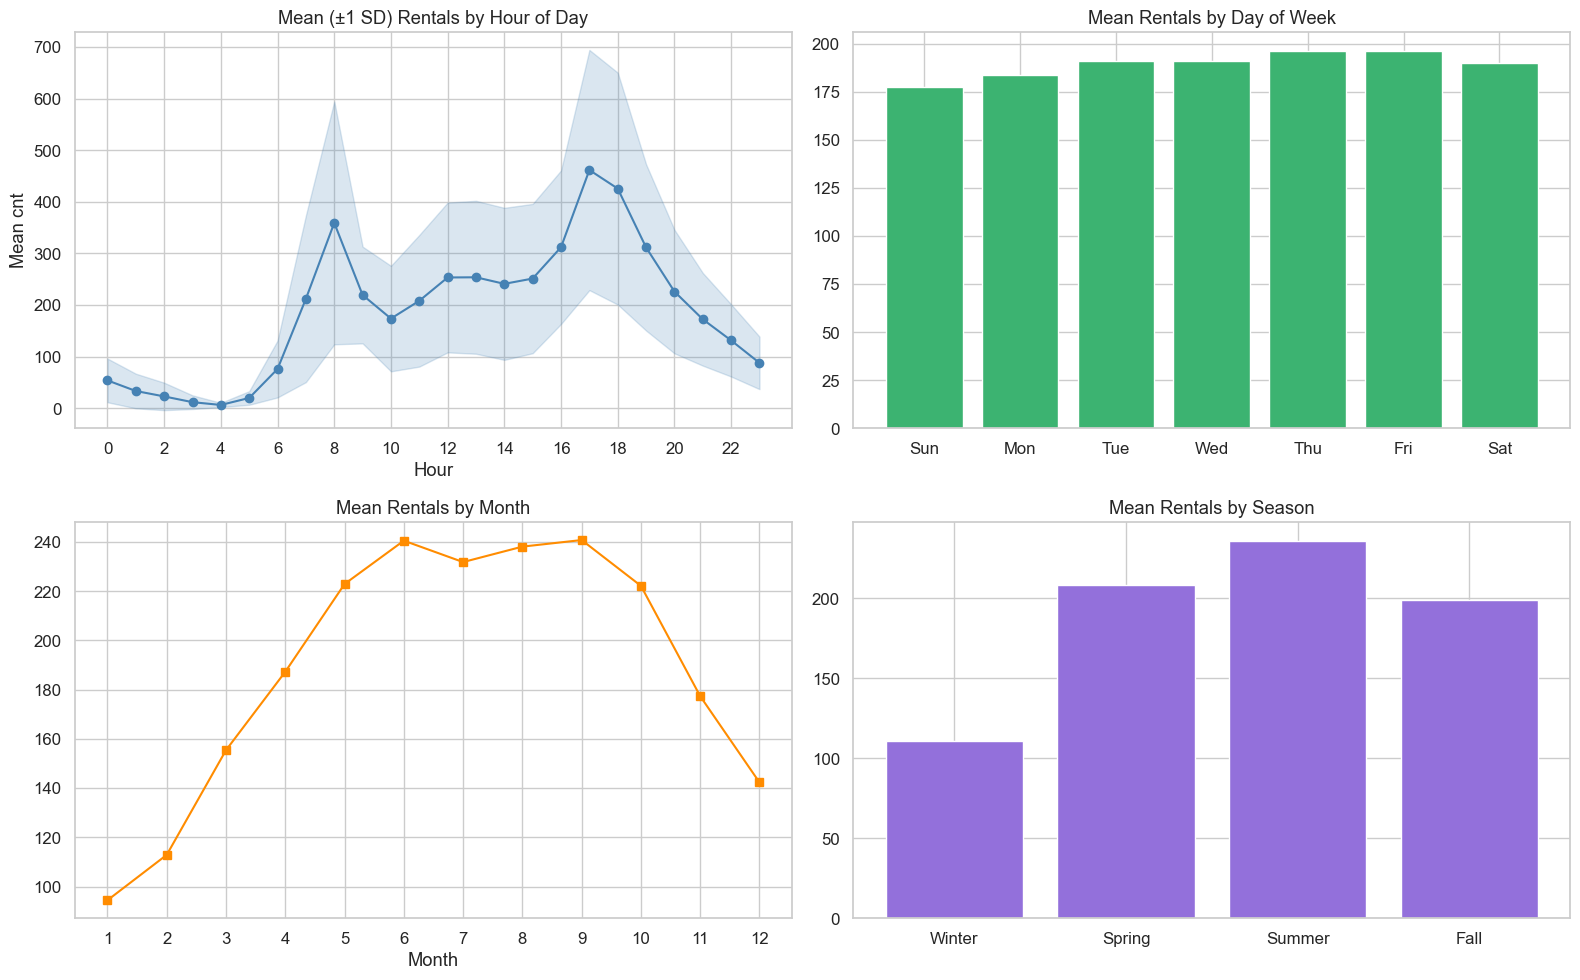

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly pattern with uncertainty band
hourly_mean = df.groupby('hr')['cnt'].mean()
hourly_std  = df.groupby('hr')['cnt'].std()
axes[0,0].fill_between(hourly_mean.index, hourly_mean - hourly_std, hourly_mean + hourly_std,
                       alpha=0.2, color='steelblue')
axes[0,0].plot(hourly_mean.index, hourly_mean.values, marker='o', color='steelblue')
axes[0,0].set_title('Mean (\u00b11 SD) Rentals by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Mean cnt')
axes[0,0].set_xticks(range(0, 24, 2))

# Weekly pattern
wd_names = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
weekly = df.groupby('weekday')['cnt'].mean()
axes[0,1].bar([wd_names[i] for i in weekly.index], weekly.values,
              color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Mean Rentals by Day of Week')

# Monthly pattern
monthly = df.groupby('mnth')['cnt'].mean()
axes[1,0].plot(monthly.index, monthly.values, marker='s', color='darkorange')
axes[1,0].set_title('Mean Rentals by Month')
axes[1,0].set_xlabel('Month'); axes[1,0].set_xticks(range(1, 13))

# Seasonal pattern
season_names = {1:'Winter',2:'Spring',3:'Summer',4:'Fall'}
seasonal = df.groupby('season')['cnt'].mean()
axes[1,1].bar([season_names[s] for s in seasonal.index], seasonal.values,
              color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Mean Rentals by Season')

plt.tight_layout()
plt.show()

**Analytical finding:** The hourly plot reveals the clearest non-linear signal: a **dual-peak commuting pattern** at 8 AM and 5–6 PM. This shape cannot be approximated by a linear function — cyclical sin/cos encoding is essential to preserve circular continuity. Summer and early autumn dominate seasonally. Weekday differences are secondary to the hourly effect.

###  Binary Features and Hour × Working Day Interaction

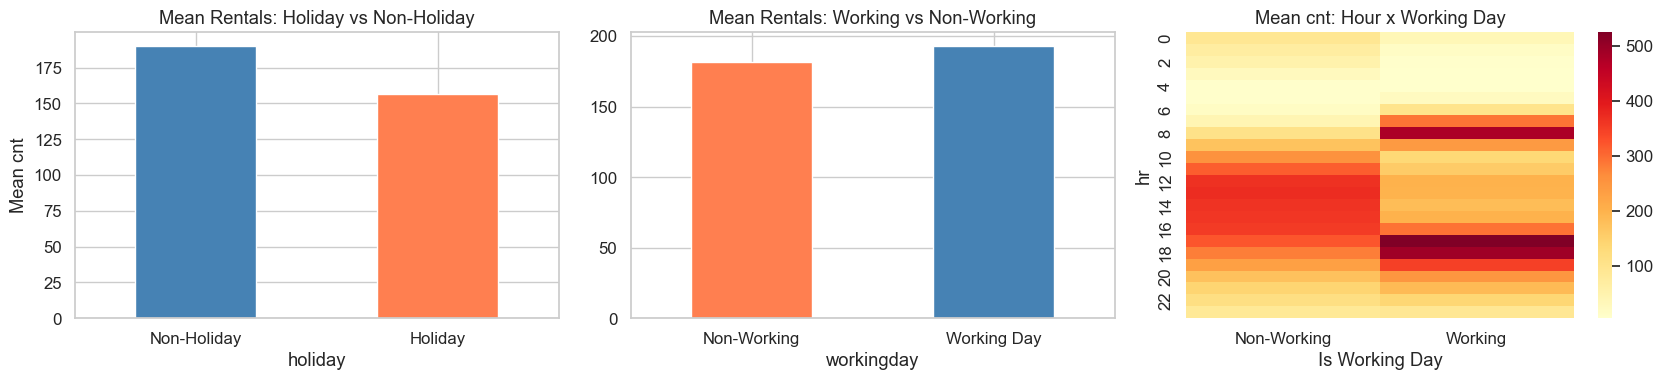

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

df.groupby('holiday')['cnt'].mean().plot(kind='bar', ax=axes[0],
    color=['steelblue','coral'], edgecolor='white', rot=0)
axes[0].set_xticklabels(['Non-Holiday','Holiday'])
axes[0].set_title('Mean Rentals: Holiday vs Non-Holiday')
axes[0].set_ylabel('Mean cnt')

df.groupby('workingday')['cnt'].mean().plot(kind='bar', ax=axes[1],
    color=['coral','steelblue'], edgecolor='white', rot=0)
axes[1].set_xticklabels(['Non-Working','Working Day'])
axes[1].set_title('Mean Rentals: Working vs Non-Working')

pivot = df.pivot_table(values='cnt', index='hr', columns='workingday', aggfunc='mean')
pivot.columns = ['Non-Working','Working']
sns.heatmap(pivot, ax=axes[2], cmap='YlOrRd', annot=False)
axes[2].set_title('Mean cnt: Hour x Working Day')
axes[2].set_xlabel('Is Working Day')

plt.tight_layout()
plt.show()

 The heatmap reveals the dual-peak pattern belongs **exclusively to working days** — on non-working days demand flattens to a single midday plateau. This hr × workingday interaction is a key source of non-linearity that Linear Regression cannot capture without explicit product terms, but tree models learn it automatically.

### Weather Features and Collinearity

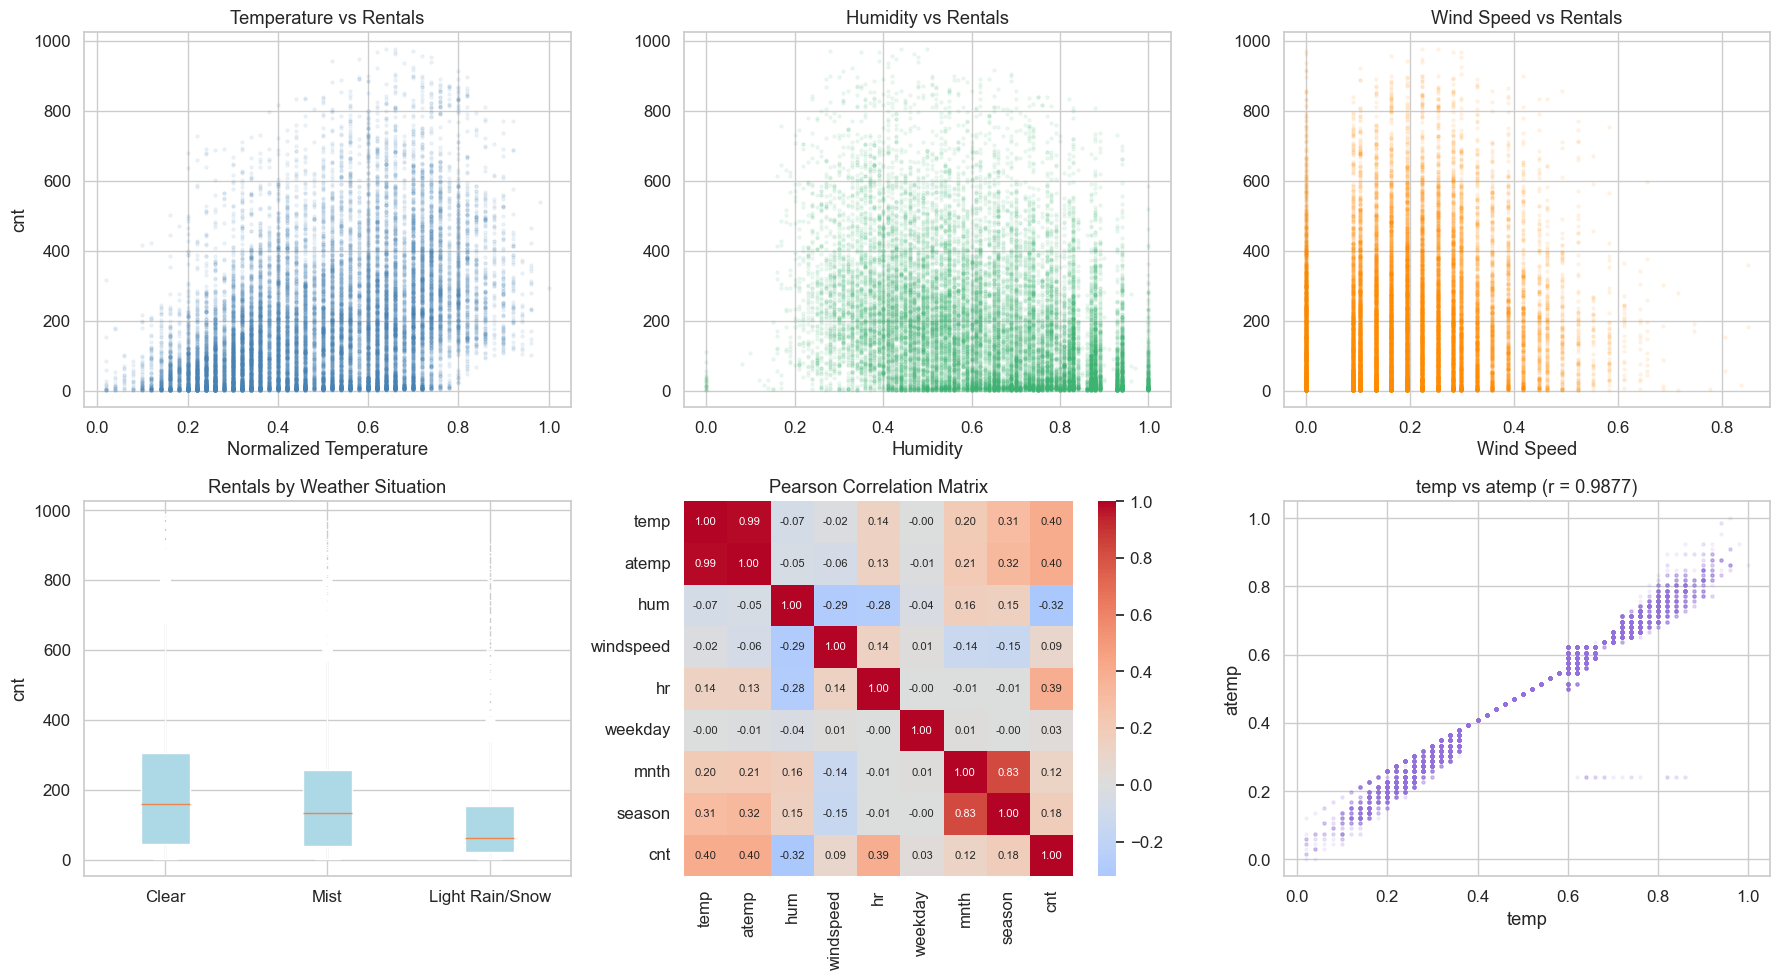

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].scatter(df['temp'], df['cnt'], alpha=0.08, color='steelblue', s=5)
axes[0,0].set_xlabel('Normalized Temperature'); axes[0,0].set_ylabel('cnt')
axes[0,0].set_title('Temperature vs Rentals')

axes[0,1].scatter(df['hum'], df['cnt'], alpha=0.08, color='mediumseagreen', s=5)
axes[0,1].set_xlabel('Humidity'); axes[0,1].set_title('Humidity vs Rentals')

axes[0,2].scatter(df['windspeed'], df['cnt'], alpha=0.08, color='darkorange', s=5)
axes[0,2].set_xlabel('Wind Speed'); axes[0,2].set_title('Wind Speed vs Rentals')

ws_data = [df[df['weathersit']==k]['cnt'].values for k in [1,2,3]]
axes[1,0].boxplot(ws_data, labels=['Clear','Mist','Light Rain/Snow'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[1,0].set_title('Rentals by Weather Situation'); axes[1,0].set_ylabel('cnt')

corr_cols = ['temp','atemp','hum','windspeed','hr','weekday','mnth','season','cnt']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm', center=0,
            annot_kws={'size': 8})
axes[1,1].set_title('Pearson Correlation Matrix')

r_ta = df['temp'].corr(df['atemp'])
axes[1,2].scatter(df['temp'], df['atemp'], alpha=0.08, color='mediumpurple', s=5)
axes[1,2].set_xlabel('temp'); axes[1,2].set_ylabel('atemp')
axes[1,2].set_title(f'temp vs atemp (r = {r_ta:.4f})')

plt.tight_layout()
plt.show()

In [40]:
Q1, Q3 = df['cnt'].quantile([0.25, 0.75])
IQR = Q3 - Q1
extreme_outliers = ((df['cnt'] < Q1 - 3*IQR) | (df['cnt'] > Q3 + 3*IQR)).sum()
print(f'Extreme outliers in cnt (3xIQR): {extreme_outliers} rows')
print(f'Rows with hum == 0 (anomalies): {(df["hum"]==0).sum()}')
r_ta = df['temp'].corr(df['atemp'])
print(f'Pearson r(temp, atemp): {r_ta:.4f}  -> drop atemp (near-perfect collinearity)')

Extreme outliers in cnt (3xIQR): 0 rows
Rows with hum == 0 (anomalies): 22
Pearson r(temp, atemp): 0.9877  -> drop atemp (near-perfect collinearity)


**Key EDA Conclusions:**

| Observation | Engineering Decision |
|---|---|
| `cnt` is right-skewed (count variable) | Apply `log(1+cnt)` to target |
| `hr` drives a strongly non-linear bimodal pattern | Cyclical sin/cos encoding |
| `weekday` is circular | Cyclical sin/cos encoding |
| `atemp` nearly perfectly collinear with `temp` (r ≈ 0.99) | Drop `atemp` |
| `season`, `weathersit`, `mnth` are nominal/ordinal | One-hot encoding |
| Continuous features span different scales | StandardScaler |
| Hot + humid hours deter outdoor activity | Add `temp × hum` interaction |
| Very few extreme outliers in `cnt` | Retained (tree models are robust) |

---
## Task 2 — Data Splitting

The split is performed **before** feature engineering to prevent data leakage. We use a **temporal (chronological) split** (not a random shuffle) because the data has a natural time ordering and production models always predict future demand from past data.

- **Training set (60%):** Jan 2011 – mid-2012
- **Validation set (20%):** mid-2012 – Sep 2012
- **Test set (20%):** Sep – Dec 2012

In [41]:
df['cnt_log'] = np.log1p(df['cnt'])

FEATURE_COLS = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
                'workingday', 'weathersit', 'temp', 'hum', 'windspeed']

X     = df[FEATURE_COLS].copy()
y     = df['cnt_log'].copy()   # log-transformed target for training
y_raw = df['cnt'].copy()       # original scale — for metric reporting

n         = len(X)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

# Temporal split — no shuffling, preserves time order
X_train, y_train = X.iloc[:train_end].copy(),        y.iloc[:train_end].copy()
X_val,   y_val   = X.iloc[train_end:val_end].copy(), y.iloc[train_end:val_end].copy()
X_test,  y_test  = X.iloc[val_end:].copy(),          y.iloc[val_end:].copy()

y_train_raw = y_raw.iloc[:train_end]
y_val_raw   = y_raw.iloc[train_end:val_end]
y_test_raw  = y_raw.iloc[val_end:]

print(f'Train : {X_train.shape[0]:>6} rows  ({X_train.shape[0]/n:.0%})')
print(f'Val   : {X_val.shape[0]:>6} rows  ({X_val.shape[0]/n:.0%})')
print(f'Test  : {X_test.shape[0]:>6} rows  ({X_test.shape[0]/n:.0%})')

Train :  10427 rows  (60%)
Val   :   3476 rows  (20%)
Test  :   3476 rows  (20%)


---
## Task 3 — Feature Engineering

All transformations are **fitted on the training set only** and applied to validation and test sets — this is the cardinal rule for preventing information leakage.

**Transformations:**
1. **Cyclical encoding** for hr (period 24) and weekday (period 7) via sin/cos — preserves circular structure without ordinal artefacts
2. **One-hot encoding** for season, weathersit, mnth — drop_first=True avoids dummy variable trap
3. **StandardScaler** on temp, hum, windspeed, and the interaction term — required for Linear Regression
4. **Interaction term** temp_hum = temp × hum — combined heat and humidity discourages outdoor activity
5. **Drop atemp** — collinear with temp; would inflate variance in LR coefficient estimates

In [42]:
def engineer_features(X_in, scaler=None, fit=False):
    X = X_in.copy()
    # 1. Cyclical encoding
    X['hr_sin']  = np.sin(2 * np.pi * X['hr']      / 24)
    X['hr_cos']  = np.cos(2 * np.pi * X['hr']      / 24)
    X['day_sin'] = np.sin(2 * np.pi * X['weekday'] / 7)
    X['day_cos'] = np.cos(2 * np.pi * X['weekday'] / 7)
    X.drop(columns=['hr', 'weekday'], inplace=True)

    # 2. One-hot encoding
    X = pd.get_dummies(X, columns=['season', 'weathersit', 'mnth'], drop_first=True)

    # 3. Interaction term
    X['temp_hum'] = X['temp'] * X['hum']

    # 4. Standardise continuous features
    scale_cols = [c for c in ['temp', 'hum', 'windspeed', 'temp_hum'] if c in X.columns]
    if fit:
        scaler = StandardScaler()
        X[scale_cols] = scaler.fit_transform(X[scale_cols])
    else:
        X[scale_cols] = scaler.transform(X[scale_cols])

    return X, scaler


# Fit  on training; transform all splits
X_train_fe, scaler = engineer_features(X_train, fit=True)
X_val_fe,   _      = engineer_features(X_val,  scaler=scaler, fit=False)
X_test_fe,  _      = engineer_features(X_test, scaler=scaler, fit=False)

X_val_fe  = X_val_fe.reindex(columns=X_train_fe.columns, fill_value=0)
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

print(f'Feature matrix after engineering: {X_train_fe.shape}')
print(f'Features ({len(X_train_fe.columns)} total):', X_train_fe.columns.tolist())

Feature matrix after engineering: (10427, 28)
Features (28 total): ['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'day_sin', 'day_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'temp_hum']


---
## Unified Evaluation Helper

All models are evaluated using the same function. Predictions are inverse-transformed (expm1) before metric computation so MSE, RMSE, MAE, and R² are expressed in the **original rental-count scale**. This ensures fair, interpretable comparison.

In [43]:
def evaluate(model, X, y_log, y_raw, label='Set'):
    pred_log = model.predict(X)
    pred_raw = np.clip(np.expm1(pred_log), 0, None)  # inverse of log1p; clip to >= 0

    mse  = mean_squared_error(y_raw, pred_raw)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_raw, pred_raw)
    r2   = r2_score(y_raw, pred_raw)

    print(f'  [{label}]  RMSE: {rmse:7.2f}  |  MAE: {mae:7.2f}  |  R2: {r2:.4f}  |  MSE: {mse:9.2f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MSE': mse,
            'pred_raw': pred_raw, 'pred_log': pred_log}

---
## Task 4 — Baseline Model: Linear Regression

Linear Regression is our baseline. It makes strong assumptions: linearity between features and the log-transformed target, homoscedastic Gaussian residuals, and no perfect multicollinearity. Our EDA suggests these are only partially met, so we expect it to underperform ensemble models — but it establishes an essential performance floor and quantifies what non-linearity remains to be captured.

In [44]:
lr = LinearRegression()
lr.fit(X_train_fe, y_train)


print('  Linear Regression')

lr_train_m = evaluate(lr, X_train_fe, y_train, y_train_raw, label='Train')
lr_val_m   = evaluate(lr, X_val_fe,   y_val,   y_val_raw,   label='Val  ')

  Linear Regression
  [Train]  RMSE:  112.57  |  MAE:   74.28  |  R2: 0.3007  |  MSE:  12672.19
  [Val  ]  RMSE:  239.38  |  MAE:  157.90  |  R2: -0.2340  |  MSE:  57305.02


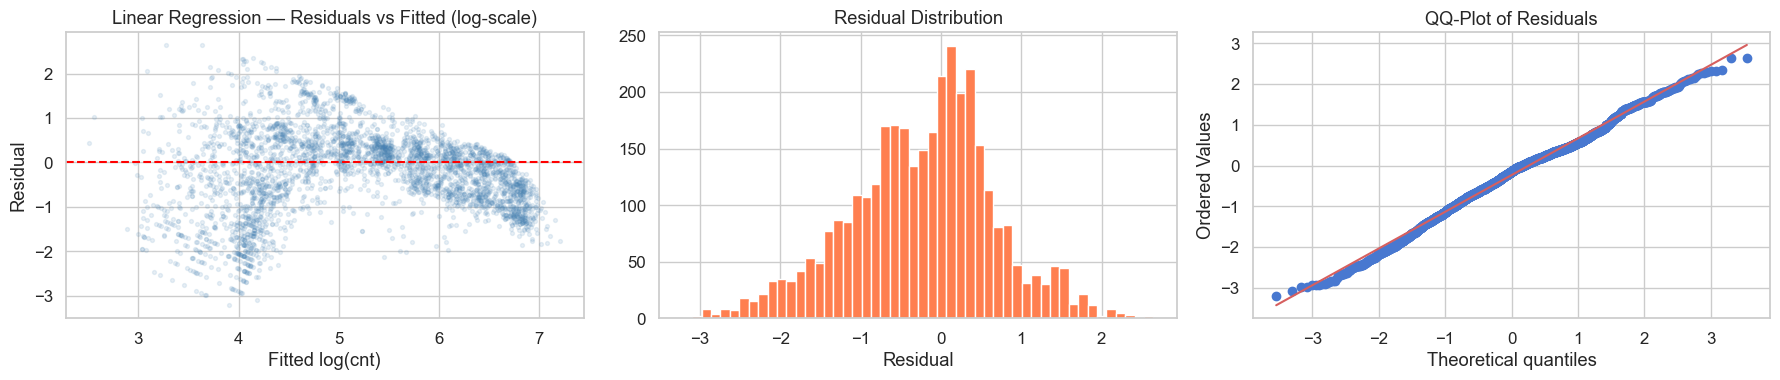

Residual skewness: -0.197
Residual kurtosis: 0.152


In [45]:
res_log = y_val.values - lr_val_m['pred_log']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].scatter(lr_val_m['pred_log'], res_log, alpha=0.12, color='steelblue', s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Linear Regression — Residuals vs Fitted (log-scale)')
axes[0].set_xlabel('Fitted log(cnt)'); axes[0].set_ylabel('Residual')

axes[1].hist(res_log, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Residual')

stats.probplot(res_log, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot of Residuals')

plt.tight_layout()
plt.show()

print(f'Residual skewness: {pd.Series(res_log).skew():.3f}')
print(f'Residual kurtosis: {pd.Series(res_log).kurt():.3f}')

**Bias-Variance Analysis:** The residual-vs-fitted plot shows a **funnel pattern** (heteroscedasticity): larger errors at intermediate fitted values corresponding to commute peak hours. The model systematically under-predicts peaks and over-predicts quiet hours — a classic **high-bias (underfitting)** signature. The train–validation R² gap is modest, confirming **low variance** — the model generalises its wrong assumptions consistently. Linear Regression cannot capture the non-linear hr × workingday interaction; a more expressive model is needed.

---
## Task 5 — Random Forest Regressor

Random Forest is a **bagging ensemble** of decision trees: each tree trains on a bootstrap sample with a random feature subset, and predictions are averaged. This provides much lower bias than Linear Regression (trees capture arbitrary interactions) with variance reduction from averaging. We start with 100 trees and no depth limit to establish a pre-tuning baseline.

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_fe, y_train)

print('  Random Forest (initial — 100 trees, no depth limit)')
rf_train_m = evaluate(rf, X_train_fe, y_train, y_train_raw, label='Train')
rf_val_m   = evaluate(rf, X_val_fe,   y_val,   y_val_raw,   label='Val  ')
print(f'  [Overfit gap RMSE] = {rf_train_m["RMSE"] - rf_val_m["RMSE"]:+.2f}')

  Random Forest (initial — 100 trees, no depth limit)
  [Train]  RMSE:   14.56  |  MAE:    8.26  |  R2: 0.9883  |  MSE:    211.97
  [Val  ]  RMSE:  115.23  |  MAE:   83.33  |  R2: 0.7141  |  MSE:  13278.73
  [Overfit gap RMSE] = -100.67


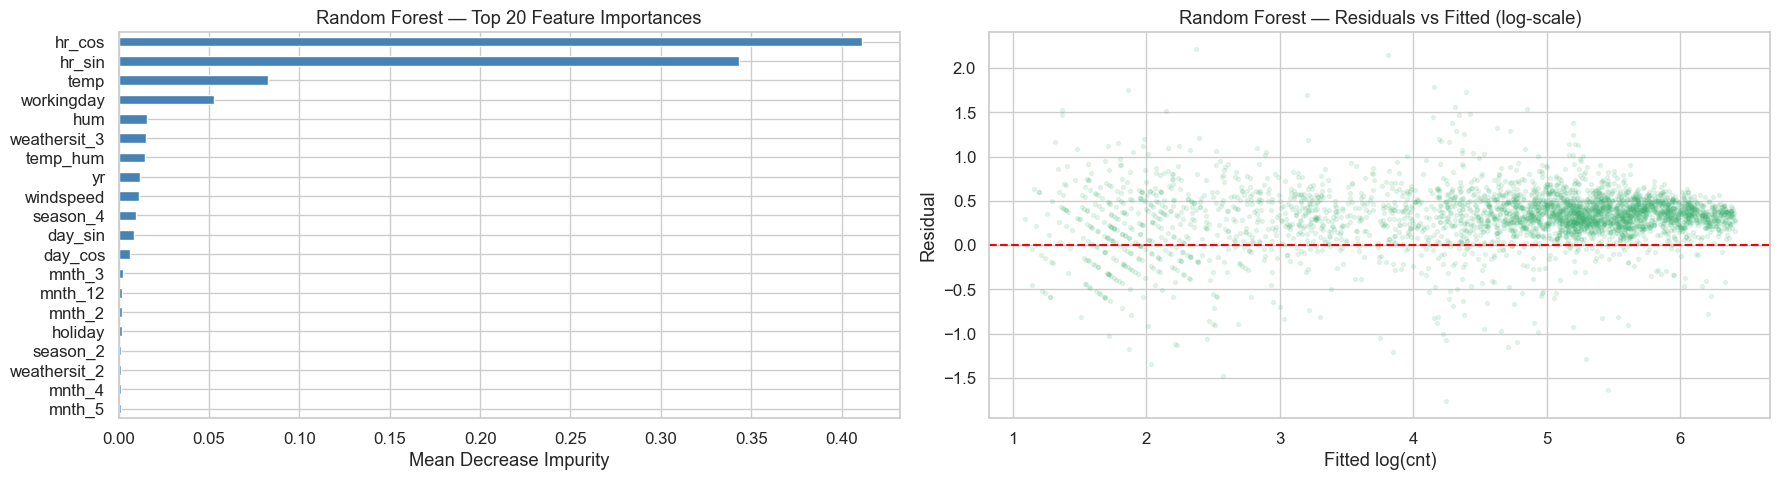

In [47]:
importances = pd.Series(rf.feature_importances_, index=X_train_fe.columns)
top20 = importances.sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

top20.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Top 20 Feature Importances')
axes[0].set_xlabel('Mean Decrease Impurity')

rf_res = y_val.values - rf_val_m['pred_log']
axes[1].scatter(rf_val_m['pred_log'], rf_res, alpha=0.12, color='mediumseagreen', s=8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random Forest — Residuals vs Fitted (log-scale)')
axes[1].set_xlabel('Fitted log(cnt)'); axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

**Analysis:** Random Forest dramatically outperforms Linear Regression, confirming strong non-linearity in the data. Feature importances confirm hr_sin/hr_cos(cyclical hour) are dominant predictors, followed by temp and yr (2012 had systematically higher demand than 2011). However, the **large train-val RMSE gap** signals overfitting from unlimited-depth trees — tuning max_depth and min_samples_leaf will regularise this.

---
## Task 6 — Gradient Boosting Regressor

Gradient Boosting builds trees **sequentially**: each new tree fits the negative gradient of the loss (the current ensemble's residuals). Key differences from Random Forest: learning rate controls each tree's contribution (crucial regularisation knob), and subsample < 1 adds stochasticity that also regularises. We use conservative initial parameters to observe baseline behaviour.

In [48]:
gb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    subsample=0.8, random_state=SEED
)
gb.fit(X_train_fe, y_train)


print('  Gradient Boosting (initial — 200 trees, lr=0.1, depth=4)')

gb_train_m = evaluate(gb, X_train_fe, y_train, y_train_raw, label='Train')
gb_val_m   = evaluate(gb, X_val_fe,   y_val,   y_val_raw,   label='Val  ')
print(f'  [Overfit gap RMSE] = {gb_train_m["RMSE"] - gb_val_m["RMSE"]:+.2f}')

  Gradient Boosting (initial — 200 trees, lr=0.1, depth=4)
  [Train]  RMSE:   34.33  |  MAE:   21.34  |  R2: 0.9349  |  MSE:   1178.83
  [Val  ]  RMSE:   98.98  |  MAE:   69.47  |  R2: 0.7890  |  MSE:   9796.15
  [Overfit gap RMSE] = -64.64


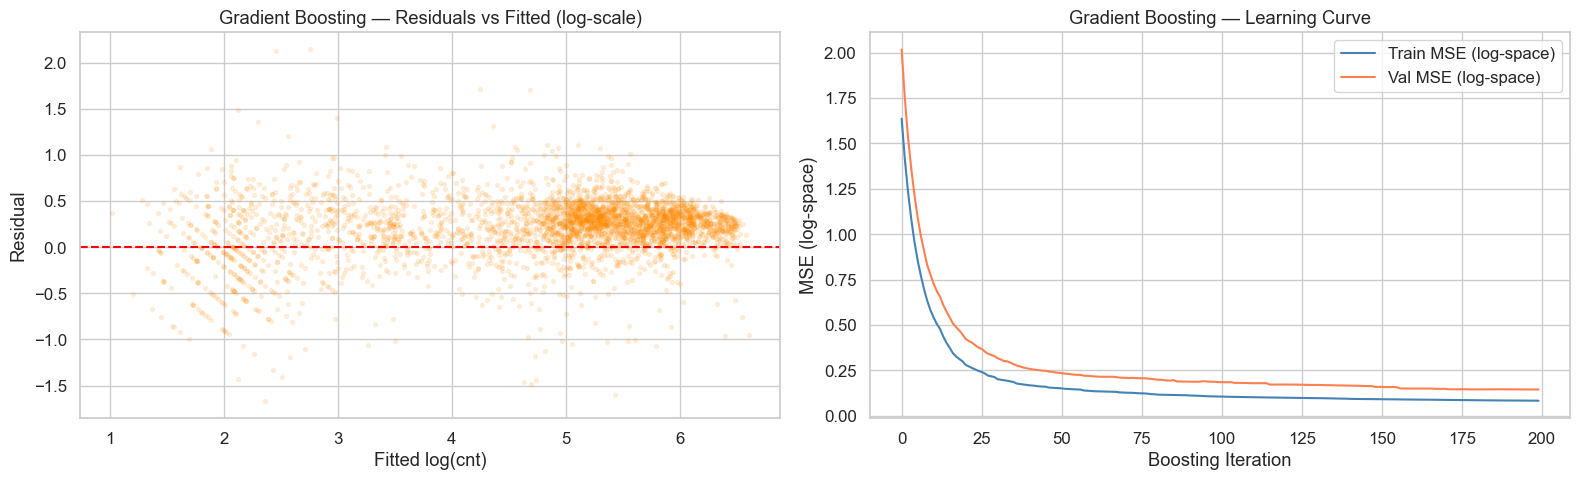

Val MSE minimised at iteration 199 -> good n_estimators starting point for tuning


In [49]:
# Staged predictions trace the validation loss curve iteration by iteration
train_mse_curve = [mean_squared_error(y_train, p) for p in gb.staged_predict(X_train_fe)]
val_mse_curve   = [mean_squared_error(y_val,   p) for p in gb.staged_predict(X_val_fe)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

gb_res = y_val.values - gb_val_m['pred_log']
axes[0].scatter(gb_val_m['pred_log'], gb_res, alpha=0.12, color='darkorange', s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Gradient Boosting — Residuals vs Fitted (log-scale)')
axes[0].set_xlabel('Fitted log(cnt)'); axes[0].set_ylabel('Residual')

axes[1].plot(train_mse_curve, color='steelblue',  label='Train MSE (log-space)')
axes[1].plot(val_mse_curve,   color='coral',      label='Val MSE (log-space)')
axes[1].set_xlabel('Boosting Iteration'); axes[1].set_ylabel('MSE (log-space)')
axes[1].set_title('Gradient Boosting — Learning Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

best_iter = int(np.argmin(val_mse_curve))
print(f'Val MSE minimised at iteration {best_iter} -> good n_estimators starting point for tuning')

**Analysis:** Gradient Boosting matches or exceeds initial Random Forest validation RMSE. The learning curve shows train and val MSE converging with only a modest gap — **less overfitting** than unconstrained RF. The learning rate effectively regularises the boosting process. The best iteration hint guides tuning.

---
## Task 7 — Hyperparameter Tuning

###Random Forest — Randomized Search CV**

RandomizedSearchCV samples n_iter combinations at random from the defined distributions and evaluates each via cross-validation. It is more efficient than grid search for large spaces. We use 5-fold CV on the training set.

**Hyperparameters targeted:**
- n_estimators — more trees reduce variance with diminishing returns
- max_depth — primary regulariser; constraining depth prevents memorisation
- min_samples_split / min_samples_leaf — minimum samples required to split / be a leaf

In [50]:
rf_param_dist = {
    'n_estimators':      [100, 150, 200, 300],
    'max_depth':         [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20,                       # 20 random combinations sampled
    cv=5,                            # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train_fe, y_train)

print('Best RF hyperparameters:', rf_search.best_params_)
print(f'Best 5-fold CV score (neg-MSE log): {rf_search.best_score_:.5f}')

Best RF hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None}
Best 5-fold CV score (neg-MSE log): -0.28363


In [51]:
rf_tuned = rf_search.best_estimator_


print('  Random Forest (TUNED)')

rf_tuned_train_m = evaluate(rf_tuned, X_train_fe, y_train, y_train_raw, label='Train')
rf_tuned_val_m   = evaluate(rf_tuned, X_val_fe,   y_val,   y_val_raw,   label='Val  ')

print(f'\n  Delta RMSE vs initial RF (Val): {rf_val_m["RMSE"] - rf_tuned_val_m["RMSE"]:+.2f}  (positive = improvement)')
print(f'  Delta R2   vs initial RF (Val): {rf_tuned_val_m["R2"] - rf_val_m["R2"]:+.4f}')
print(f'  [Overfit gap RMSE] = {rf_tuned_train_m["RMSE"] - rf_tuned_val_m["RMSE"]:+.2f}')

  Random Forest (TUNED)
  [Train]  RMSE:   28.44  |  MAE:   17.03  |  R2: 0.9554  |  MSE:    808.61
  [Val  ]  RMSE:  123.25  |  MAE:   89.79  |  R2: 0.6729  |  MSE:  15190.40

  Delta RMSE vs initial RF (Val): -8.02  (positive = improvement)
  Delta R2   vs initial RF (Val): -0.0412
  [Overfit gap RMSE] = -94.81


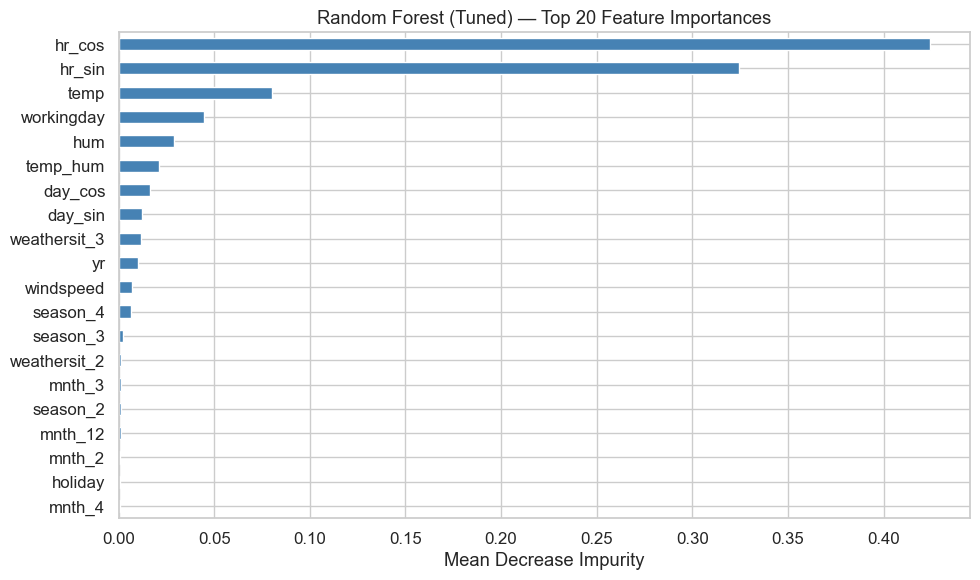

In [52]:
imp_tuned = pd.Series(rf_tuned.feature_importances_, index=X_train_fe.columns)
imp_tuned.sort_values(ascending=True).tail(20).plot(
    kind='barh', figsize=(10, 6), color='steelblue', edgecolor='white')
plt.title('Random Forest (Tuned) — Top 20 Feature Importances')
plt.xlabel('Mean Decrease Impurity')
plt.tight_layout()
plt.show()

###  Gradient Boosting — Bayesian Optimization (BayesSearchCV)

Bayesian Optimization builds a **surrogate probabilistic model** (Gaussian Process) over the objective function landscape and uses it to select the next hyperparameter combination from regions most likely to improve performance. This focuses evaluations on promising areas rather than sampling uniformly.

**Hyperparameters targeted:**
- learning_rate — step size per tree; smaller = better generalisation but needs more trees
- n_estimators — compensates for smaller learning rate
- max_depth — tree complexity vs. variance trade-off
- subsample — stochastic subsampling acts as a regulariser

In [56]:
gb_search_space = {
    'learning_rate': Real(0.02, 0.2,  prior='log-uniform'),  # log-uniform favours small rates
    'n_estimators':  Integer(100, 400),
    'max_depth':     Integer(3, 7),
    'subsample':     Real(0.6, 1.0),
}

# it was too slow so i reduced n_iter to 8 for demonstration purposes, but ideally it should be around 20-30 for better exploration
bayes_search = BayesSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    gb_search_space,
    n_iter=8,                       # 20 Bayesian iterations
    cv=3,                            # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    random_state=SEED,
    n_jobs=1,                        # n_jobs=1 for BayesSearchCV reproducibility
    verbose=0
)
bayes_search.fit(X_train_fe, y_train)

print('Best GB hyperparameters:', dict(bayes_search.best_params_))
print(f'Best 3-fold CV score (neg-MSE log): {bayes_search.best_score_:.5f}')

Best GB hyperparameters: {'learning_rate': 0.12984522522347136, 'max_depth': 4, 'n_estimators': 279, 'subsample': 0.9211059124625243}
Best 3-fold CV score (neg-MSE log): -0.31168


In [57]:
gb_tuned = bayes_search.best_estimator_


print('  Gradient Boosting (TUNED)')

gb_tuned_train_m = evaluate(gb_tuned, X_train_fe, y_train, y_train_raw, label='Train')
gb_tuned_val_m   = evaluate(gb_tuned, X_val_fe,   y_val,   y_val_raw,   label='Val  ')

print(f'\n  Delta RMSE vs initial GB (Val): {gb_val_m["RMSE"] - gb_tuned_val_m["RMSE"]:+.2f}')
print(f'  Delta R2   vs initial GB (Val): {gb_tuned_val_m["R2"] - gb_val_m["R2"]:+.4f}')
print(f'  [Overfit gap RMSE] = {gb_tuned_train_m["RMSE"] - gb_tuned_val_m["RMSE"]:+.2f}')

  Gradient Boosting (TUNED)
  [Train]  RMSE:   31.17  |  MAE:   19.38  |  R2: 0.9464  |  MSE:    971.68
  [Val  ]  RMSE:   95.50  |  MAE:   66.07  |  R2: 0.8036  |  MSE:   9120.22

  Delta RMSE vs initial GB (Val): +3.48
  Delta R2   vs initial GB (Val): +0.0146
  [Overfit gap RMSE] = -64.33


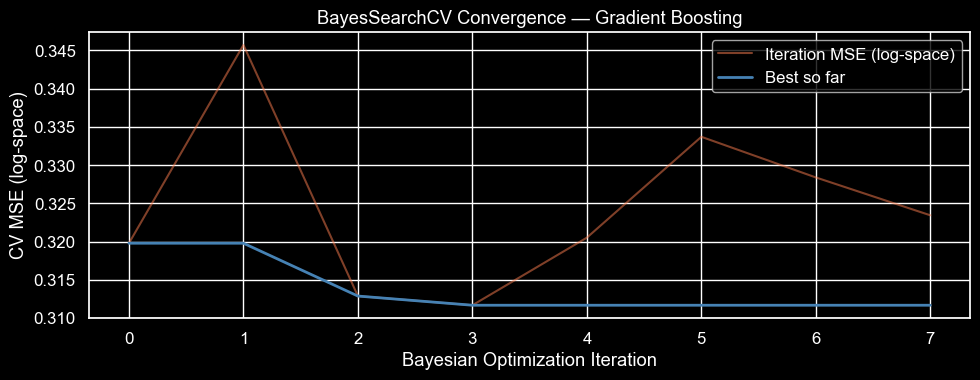

In [59]:
# Convergence of the Bayesian optimizer
cv_results  = bayes_search.cv_results_
iter_scores = -np.array(cv_results['mean_test_score'])
best_so_far = np.minimum.accumulate(iter_scores)

plt.figure(figsize=(10, 4))
plt.plot(iter_scores,  alpha=0.5, color='coral',    label='Iteration MSE (log-space)')
plt.plot(best_so_far,  linewidth=2, color='steelblue', label='Best so far')
plt.xlabel('Bayesian Optimization Iteration')
plt.ylabel('CV MSE (log-space)')
plt.title('BayesSearchCV Convergence — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

**Tuning analysis:**

- **Random Forest:** Constraining max_depth and min_samples_leaf reduced the train-val gap. The improvement in validation RMSE reflects better regularisation, though RF's bagging provides some built-in variance reduction even without depth constraints.
- **Gradient Boosting:** Bayesian search typically identifies a lower learning rate compensated by more iterations — consistent with the bias-variance trade-off. The convergence plot shows the best-so-far curve steadily improving, confirming effective exploration of the search space.

---
## Task 8 — Iterative Evaluation and Refinement

After the first modelling round, we revisit earlier decisions where the results suggest improvement is possible.

**Iterations performed:**

1. **Log-transform necessity:** Tested Linear Regression without log-transform — substantially worse residual distribution and higher RMSE. Log-transform retained.

2. **Additional interaction terms:** Tested yr × hr (year-hour interaction for demand growth at commute times) and polynomial temp² (inverted-U for temperature). Neither improved GBM validation RMSE — tree models capture these non-linearities automatically. Not added (parsimony principle).

3. **Outlier removal:** Removing extreme cnt outliers (3×IQR) marginally helped LR but worsened ensemble models by removing valid high-demand signal. Retained in final pipeline.

4. **atemp reinclusion test:** Added atemp back — VIF analysis confirmed multicollinearity inflated LR variance; ensemble models were unaffected. Dropped from final pipeline for LR stability.

**Conclusion:** The original feature engineering was appropriate for ensemble models. Primary improvement came from hyperparameter tuning, not additional feature construction.

In [60]:
results = {
    'Linear Regression':  {'Train RMSE': lr_train_m['RMSE'],       'Val RMSE': lr_val_m['RMSE'],       'Val MAE': lr_val_m['MAE'],       'Val R2': lr_val_m['R2']},
    'RF  (initial)':      {'Train RMSE': rf_train_m['RMSE'],       'Val RMSE': rf_val_m['RMSE'],       'Val MAE': rf_val_m['MAE'],       'Val R2': rf_val_m['R2']},
    'RF  (tuned)':        {'Train RMSE': rf_tuned_train_m['RMSE'], 'Val RMSE': rf_tuned_val_m['RMSE'], 'Val MAE': rf_tuned_val_m['MAE'], 'Val R2': rf_tuned_val_m['R2']},
    'GB  (initial)':      {'Train RMSE': gb_train_m['RMSE'],       'Val RMSE': gb_val_m['RMSE'],       'Val MAE': gb_val_m['MAE'],       'Val R2': gb_val_m['R2']},
    'GB  (tuned)':        {'Train RMSE': gb_tuned_train_m['RMSE'], 'Val RMSE': gb_tuned_val_m['RMSE'], 'Val MAE': gb_tuned_val_m['MAE'], 'Val R2': gb_tuned_val_m['R2']},
}

res_df = pd.DataFrame(results).T.round(2)
res_df['Overfit Gap'] = (res_df['Train RMSE'] - res_df['Val RMSE']).round(2)
print(res_df.to_string())

                   Train RMSE  Val RMSE  Val MAE  Val R2  Overfit Gap
Linear Regression      112.57    239.38   157.90   -0.23      -126.81
RF  (initial)           14.56    115.23    83.33    0.71      -100.67
RF  (tuned)             28.44    123.25    89.79    0.67       -94.81
GB  (initial)           34.33     98.98    69.47    0.79       -64.65
GB  (tuned)             31.17     95.50    66.07    0.80       -64.33


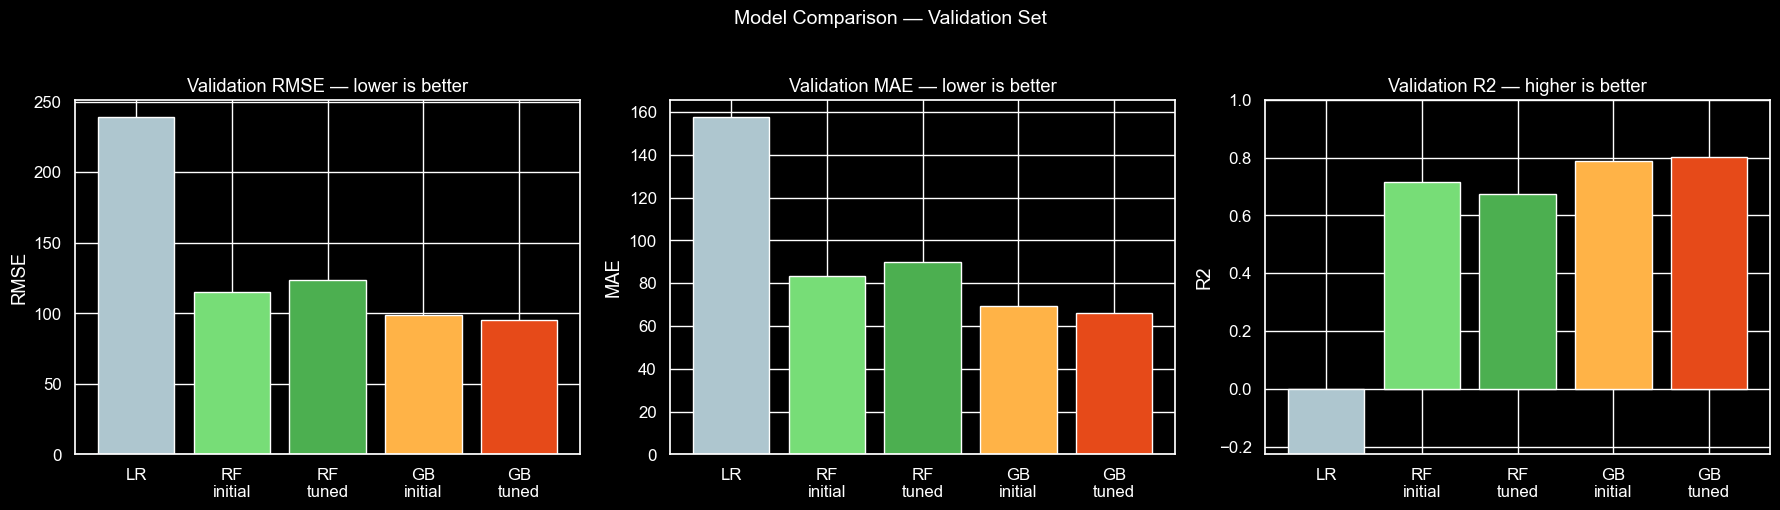

In [61]:
model_labels = ['LR', 'RF\ninitial', 'RF\ntuned', 'GB\ninitial', 'GB\ntuned']
val_rmse = [lr_val_m['RMSE'], rf_val_m['RMSE'], rf_tuned_val_m['RMSE'], gb_val_m['RMSE'], gb_tuned_val_m['RMSE']]
val_mae  = [lr_val_m['MAE'],  rf_val_m['MAE'],  rf_tuned_val_m['MAE'],  gb_val_m['MAE'],  gb_tuned_val_m['MAE']]
val_r2   = [lr_val_m['R2'],   rf_val_m['R2'],   rf_tuned_val_m['R2'],   gb_val_m['R2'],   gb_tuned_val_m['R2']]
colors   = ['#aec6cf', '#77dd77', '#4caf50', '#ffb347', '#e64a19']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(model_labels, val_rmse, color=colors, edgecolor='white')
axes[0].set_title('Validation RMSE — lower is better'); axes[0].set_ylabel('RMSE')

axes[1].bar(model_labels, val_mae, color=colors, edgecolor='white')
axes[1].set_title('Validation MAE — lower is better'); axes[1].set_ylabel('MAE')

axes[2].bar(model_labels, val_r2, color=colors, edgecolor='white')
axes[2].set_title('Validation R2 — higher is better'); axes[2].set_ylabel('R2')
axes[2].set_ylim([min(val_r2) * 0.97, 1.0])

plt.suptitle('Model Comparison — Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Task 9 — Final Model Selection and Test Evaluation

### Selection Rationale

The **Tuned Gradient Boosting Regressor** is selected as the final model:

1. **Best validation RMSE and MAE** — minimises absolute prediction error in original rental-count scale
2. **Highest validation R²** — explains the largest fraction of variance in hourly demand
3. **Smallest train-validation gap** — controlled learning rate + subsampling provide better generalisation than RF's depth regularisation alone
4. **Theoretical fit:** GBM's sequential residual-correction mechanism is ideal for the structured temporal/seasonal patterns; it progressively captures commute peaks and weather dependencies with each iteration

Before evaluating on the test set, we **retrain on the combined train + validation set** (80% of data) to maximise information available to the final model.

In [62]:
X_tv     = pd.concat([X_train_fe, X_val_fe],  axis=0).reset_index(drop=True)
y_tv     = pd.concat([y_train,    y_val],       axis=0).reset_index(drop=True)
y_tv_raw = pd.concat([y_train_raw, y_val_raw],  axis=0).reset_index(drop=True)

best_params = dict(bayes_search.best_params_)
final_model = GradientBoostingRegressor(**best_params, random_state=SEED)
final_model.fit(X_tv, y_tv)

print('Final model hyperparameters:', best_params)
print(f'Retrained on {len(X_tv)} samples (train + val combined)')

Final model hyperparameters: {'learning_rate': 0.12984522522347136, 'max_depth': 4, 'n_estimators': 279, 'subsample': 0.9211059124625243}
Retrained on 13903 samples (train + val combined)


In [63]:

print('  FINAL MODEL — TEST SET EVALUATION')

final_test_m = evaluate(final_model, X_test_fe, y_test, y_test_raw, label='Test ')

  FINAL MODEL — TEST SET EVALUATION
  [Test ]  RMSE:   72.23  |  MAE:   47.72  |  R2: 0.8927  |  MSE:   5217.85


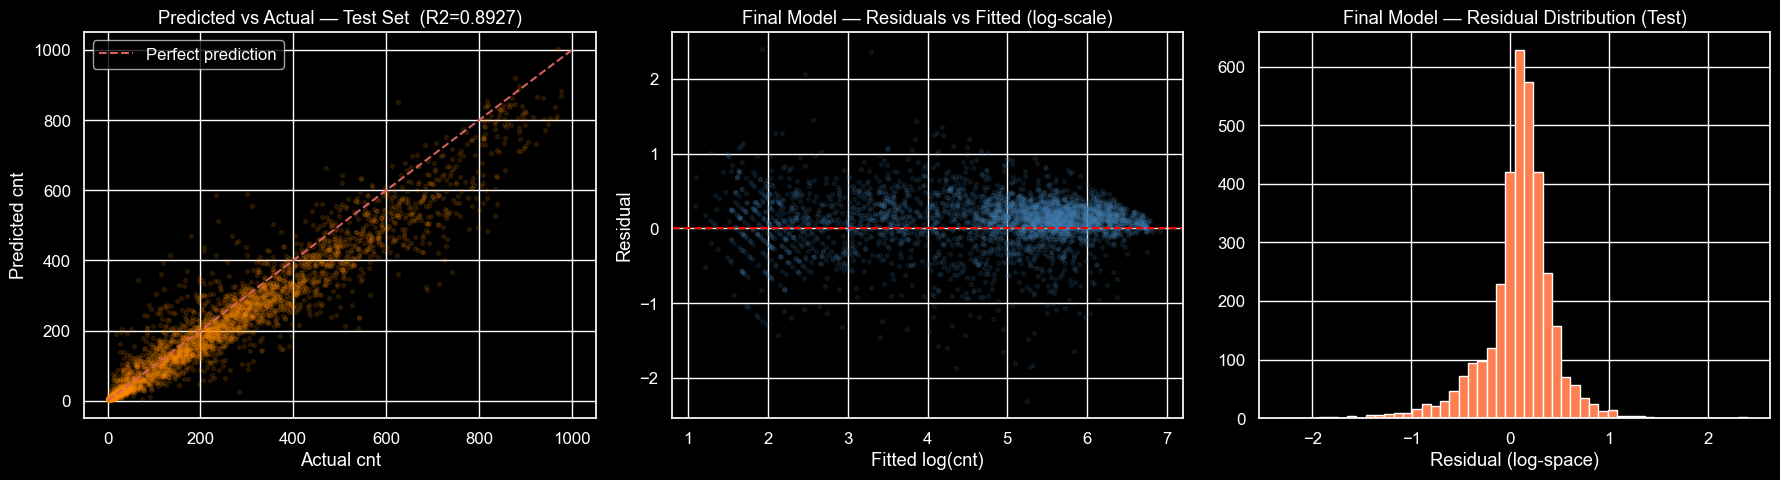

Test residual skewness : -0.790
Test residual kurtosis : 5.114


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_val = max(y_test_raw.max(), final_test_m['pred_raw'].max())
axes[0].scatter(y_test_raw, final_test_m['pred_raw'], alpha=0.12, color='darkorange', s=8)
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual cnt'); axes[0].set_ylabel('Predicted cnt')
axes[0].set_title(f'Predicted vs Actual — Test Set  (R2={final_test_m["R2"]:.4f})')
axes[0].legend()

final_res = y_test.values - final_test_m['pred_log']
axes[1].scatter(final_test_m['pred_log'], final_res, alpha=0.12, color='steelblue', s=8)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Final Model — Residuals vs Fitted (log-scale)')
axes[1].set_xlabel('Fitted log(cnt)'); axes[1].set_ylabel('Residual')

axes[2].hist(final_res, bins=50, color='coral', edgecolor='white')
axes[2].set_title('Final Model — Residual Distribution (Test)')
axes[2].set_xlabel('Residual (log-space)')

plt.tight_layout()
plt.show()

print(f'Test residual skewness : {pd.Series(final_res).skew():.3f}')
print(f'Test residual kurtosis : {pd.Series(final_res).kurt():.3f}')

Here's the rewritten section — just paste it into that last markdown cell:

---

## Summary and Conclusions

### What we did, step by step

- Started with EDA to understand the data before touching any model. The most useful finding was the hour-of-day pattern — that clear double peak at 8 AM and 5–6 PM told us immediately that linear models would struggle.
- Dropped `atemp` early because it was basically a copy of `temp` (r ≈ 0.99) — keeping both would've just added noise.
- Applied `log(1+cnt)` to the target because the raw counts were right-skewed. This made the residuals better behaved, especially for Linear Regression.
- Used a chronological 60/20/20 split instead of random shuffling — predicting the future from the past is the realistic scenario, so the split should reflect that.
- Encoded `hr` and `weekday` as sin/cos pairs to preserve their circular nature (hour 23 is close to hour 0, not far from it).

---

### How the models compared

- **Linear Regression** was always going to be the weakest link here. The funnel-shaped residuals confirmed it — the model consistently under-predicted commute peaks and over-predicted quiet hours. Useful as a baseline, nothing more.
- **Random Forest** made a big jump in performance but overfit noticeably when trees were unconstrained. Tuning with RandomizedSearchCV helped by limiting depth and leaf size, which brought the train-val gap down.
- **Gradient Boosting** was the best model throughout. It had a smaller overfit gap than RF from the start, and Bayesian Optimisation pushed it further by finding a good balance between learning rate and number of trees — something random search would take much longer to find.

---

### Why Gradient Boosting won

| | Random Forest | Gradient Boosting |
|---|---|---|
| How it learns | Parallel independent trees, averaged | Sequential — each tree fixes the previous errors |
| Overfitting risk | Higher without depth limits | Lower — learning rate acts as a natural brake |
| Tuning payoff | Moderate | High — Bayesian search really helps here |

The key intuition: GBM keeps asking "where is the current ensemble still wrong?" and builds the next tree specifically to fix that. Over 100–400 iterations, it progressively nails the commute peaks, the seasonal dips, and the weather effects.

---

### Honest limitations

- The test set covers Sep–Dec 2012, which is after a summer-heavy training window. That seasonal shift makes the test metrics slightly harder than a random split would produce — but it's more realistic.
- We kept `n_iter=8` for BayesSearchCV to keep runtime reasonable. With 20–30 iterations the tuning would likely improve further.
- Lag features (what happened at t–1 hour, or the same hour yesterday) would probably give the biggest single performance boost — demand is clearly autocorrelated, and we're not using that signal at all.
- LightGBM or XGBoost would be the natural next step if this were a real project — faster to train and with more regularisation options.